In [ ]:
%jsroot on

In [58]:
%jsroot off

# File input

In [59]:
TFile *f_pA_projectile_MB = TFile::Open("../pA_rapidityloss_MB.root");
if(!f_pA_projectile_MB || f_pA_projectile_MB->IsZombie()) { printf("File error MB\n"); return; }

TFile *f_pA_projectile_02 = TFile::Open("../pA_rapidityloss_02.root");
if(!f_pA_projectile_02 || f_pA_projectile_02->IsZombie()) { printf("File error 02\n"); return; }


# dN/dy comparison (projectile only)

In [60]:
auto h_pA_projectile_MB_dNdy = (TH1D*) f_pA_projectile_MB->Get("h_dNdy");
if(!h_pA_projectile_MB_dNdy) { printf("Histogram MB not found!\n"); return; }

auto h_pA_projectile_02_dNdy = (TH1D*) f_pA_projectile_02->Get("h_dNdy");
if(!h_pA_projectile_02_dNdy) { printf("Histogram 02 not found!\n"); return; }

## Normalization+Style

In [61]:
h_pA_projectile_MB_dNdy->Scale(1.0/h_pA_projectile_MB_dNdy->Integral());
h_pA_projectile_02_dNdy->Scale(1.0/h_pA_projectile_02_dNdy->Integral());

h_pA_projectile_MB_dNdy->SetLineColor(kRed);
h_pA_projectile_02_dNdy->SetLineStyle(2);

h_pA_projectile_MB_dNdy->SetLineWidth(2);
h_pA_projectile_02_dNdy->SetLineWidth(2);

## Draw

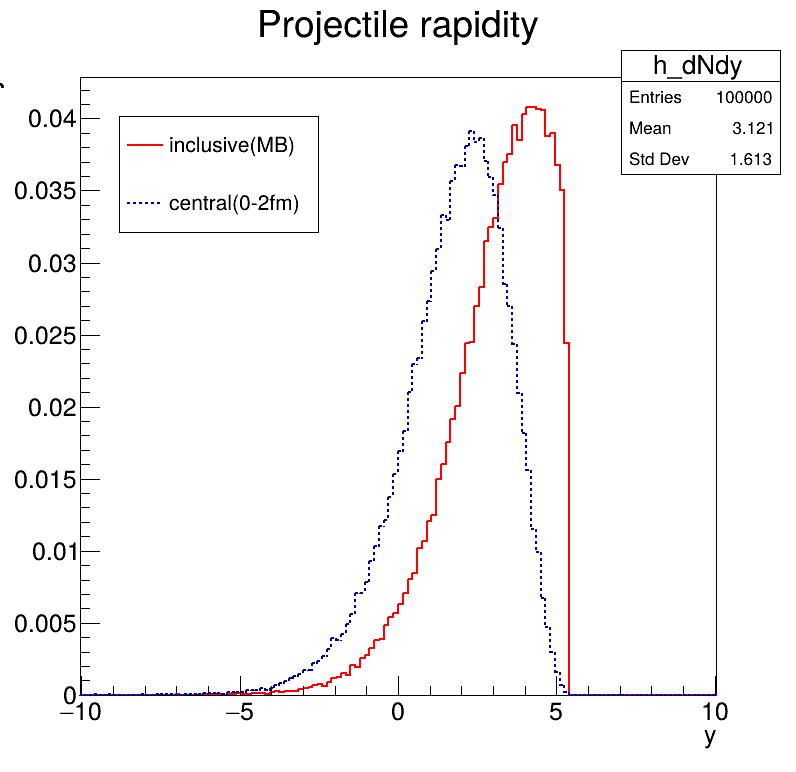

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


In [62]:
h_pA_projectile_MB_dNdy->GetXaxis()->SetRangeUser(-10,10);

auto c_dNdy = new TCanvas("c1", "pA dNdy of Projectile", 800, 800);
h_pA_projectile_MB_dNdy->Draw("HIST");
h_pA_projectile_02_dNdy->Draw("HIST SAME");


auto legend_dNdy = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy->AddEntry(h_pA_projectile_MB_dNdy, "inclusive(MB)", "l");
legend_dNdy->AddEntry(h_pA_projectile_02_dNdy, "central(0-2fm)", "l");
legend_dNdy->Draw();
c_dNdy->Draw();

# Draw Ncoll vs dNdy

In [63]:
auto h2_pA_projectile_MB_dNdy_Ncoll = (TH2D*) f_pA_projectile_MB->Get("h2_dNdy_Ncoll");
if(!h2_pA_projectile_MB_dNdy_Ncoll) { printf("Histogram not found!\n"); return; }

auto h2_pA_projectile_02_dNdy_Ncoll = (TH2D*) f_pA_projectile_02->Get("h2_dNdy_Ncoll");
if(!h2_pA_projectile_02_dNdy_Ncoll) { printf("Histogram not found!\n"); return; }

## For MB

In [64]:
// Ncoll = 1 
TH1D *h_pA_projectile_MB_dNdy_Ncoll1 = h2_pA_projectile_MB_dNdy_Ncoll->ProjectionY("h_pA_projectile_MB_dNdy_Ncoll1", h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(1), h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(1));

// Ncoll = 2
TH1D *h_pA_projectile_MB_dNdy_Ncoll2 = h2_pA_projectile_MB_dNdy_Ncoll->ProjectionY("h_pA_projectile_MB_dNdy_Ncoll2", h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(2), h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(2));

// Ncoll = 3
TH1D *h_pA_projectile_MB_dNdy_Ncoll3 = h2_pA_projectile_MB_dNdy_Ncoll->ProjectionY("h_pA_projectile_MB_dNdy_Ncoll3", h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(3), h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(3));

// Ncoll > 3
// TH1D *h_pA_projectile_MB_dNdy_NcollL = h2_pA_projectile_MB_dNdy_Ncoll->ProjectionY("h_pA_projectile_MB_dNdy_NcollL", h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(4), h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(25));
TH1D *h_pA_projectile_MB_dNdy_NcollL = h2_pA_projectile_MB_dNdy_Ncoll->ProjectionY("h_pA_projectile_MB_dNdy_NcollL", h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(10), h2_pA_projectile_MB_dNdy_Ncoll->GetXaxis()->FindBin(10));

In [65]:
h_pA_projectile_MB_dNdy_Ncoll1->Scale(1.0/h_pA_projectile_MB_dNdy_Ncoll1->Integral());
h_pA_projectile_MB_dNdy_Ncoll2->Scale(1.0/h_pA_projectile_MB_dNdy_Ncoll2->Integral());
h_pA_projectile_MB_dNdy_Ncoll3->Scale(1.0/h_pA_projectile_MB_dNdy_Ncoll3->Integral());
h_pA_projectile_MB_dNdy_NcollL->Scale(1.0/h_pA_projectile_MB_dNdy_NcollL->Integral());

h_pA_projectile_MB_dNdy_Ncoll1->SetLineColor(kRed);
h_pA_projectile_MB_dNdy_Ncoll2->SetLineColor(kBlue);
h_pA_projectile_MB_dNdy_Ncoll3->SetLineColor(kGreen);
h_pA_projectile_MB_dNdy_NcollL->SetLineColor(kCyan);

h_pA_projectile_MB_dNdy_Ncoll1->SetLineWidth(2);
h_pA_projectile_MB_dNdy_Ncoll2->SetLineWidth(2);
h_pA_projectile_MB_dNdy_Ncoll3->SetLineWidth(2);
h_pA_projectile_MB_dNdy_NcollL->SetLineWidth(2);

h_pA_projectile_MB_dNdy_Ncoll1->GetXaxis()->SetTitle("y");
h_pA_projectile_MB_dNdy_Ncoll2->GetXaxis()->SetTitle("y");
h_pA_projectile_MB_dNdy_Ncoll3->GetXaxis()->SetTitle("y");
h_pA_projectile_MB_dNdy_NcollL->GetXaxis()->SetTitle("y");

### Draw total

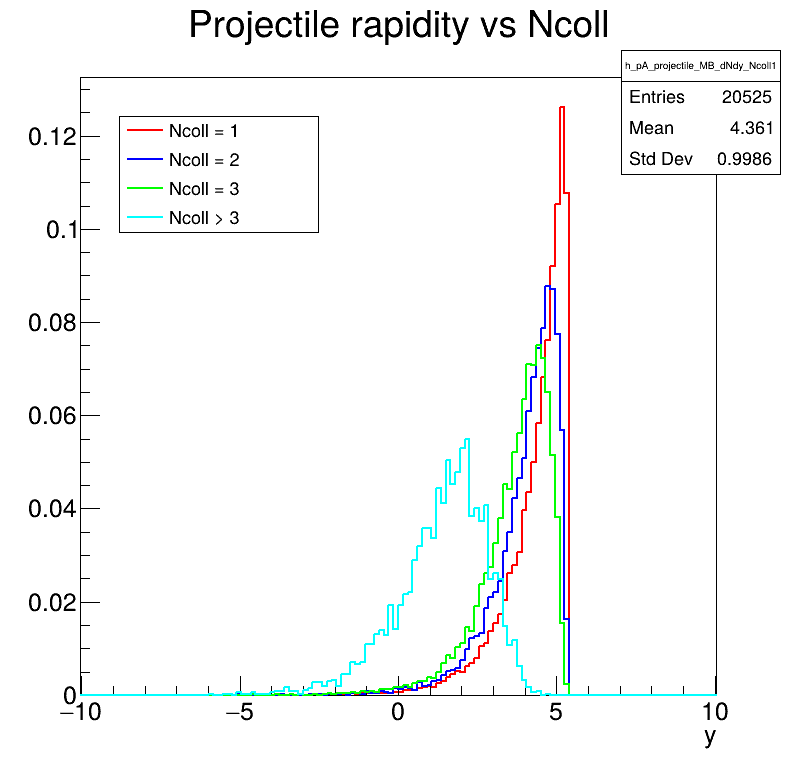

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_MB


In [ ]:
auto c_dNdy_Ncoll_MB = new TCanvas("c_dNdy_Ncoll_MB", "pA projectile dNdy", 800, 800);

h_pA_projectile_MB_dNdy_Ncoll1->GetXaxis()->SetRangeUser(-10,10);

h_pA_projectile_MB_dNdy_Ncoll1->Draw("HIST same");
h_pA_projectile_MB_dNdy_Ncoll2->Draw("HIST same");
h_pA_projectile_MB_dNdy_Ncoll3->Draw("HIST same");
h_pA_projectile_MB_dNdy_NcollL->Draw("HIST same");


auto legend_dNdy_Ncoll_MB = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy_Ncoll_MB->AddEntry(h_pA_projectile_MB_dNdy_Ncoll1, "Ncoll = 1", "l");
legend_dNdy_Ncoll_MB->AddEntry(h_pA_projectile_MB_dNdy_Ncoll2, "Ncoll = 2", "l");
legend_dNdy_Ncoll_MB->AddEntry(h_pA_projectile_MB_dNdy_Ncoll3, "Ncoll = 3", "l");
legend_dNdy_Ncoll_MB->AddEntry(h_pA_projectile_MB_dNdy_NcollL, "Ncoll = 10", "l");
legend_dNdy_Ncoll_MB->Draw();
c_dNdy_Ncoll_MB->Draw();

## For b = 0~2 fm

In [67]:
// Ncoll = 1 
TH1D *h_pA_projectile_02_dNdy_Ncoll1 = h2_pA_projectile_02_dNdy_Ncoll->ProjectionY("h_pA_projectile_02_dNdy_Ncoll1", h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(1), h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(1));

// Ncoll = 2
TH1D *h_pA_projectile_02_dNdy_Ncoll2 = h2_pA_projectile_02_dNdy_Ncoll->ProjectionY("h_pA_projectile_02_dNdy_Ncoll2", h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(2), h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(2));

// Ncoll = 3
TH1D *h_pA_projectile_02_dNdy_Ncoll3 = h2_pA_projectile_02_dNdy_Ncoll->ProjectionY("h_pA_projectile_02_dNdy_Ncoll3", h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(3), h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(3));

// Ncoll > 3
// TH1D *h_pA_projectile_02_dNdy_NcollL = h2_pA_projectile_02_dNdy_Ncoll->ProjectionY("h_pA_projectile_02_dNdy_NcollL", h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(4), h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(25));
TH1D *h_pA_projectile_02_dNdy_NcollL = h2_pA_projectile_02_dNdy_Ncoll->ProjectionY("h_pA_projectile_02_dNdy_NcollL", h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(10), h2_pA_projectile_02_dNdy_Ncoll->GetXaxis()->FindBin(10));

In [68]:
h_pA_projectile_02_dNdy_Ncoll1->Scale(1.0/h_pA_projectile_02_dNdy_Ncoll1->Integral());
h_pA_projectile_02_dNdy_Ncoll2->Scale(1.0/h_pA_projectile_02_dNdy_Ncoll2->Integral());
h_pA_projectile_02_dNdy_Ncoll3->Scale(1.0/h_pA_projectile_02_dNdy_Ncoll3->Integral());
h_pA_projectile_02_dNdy_NcollL->Scale(1.0/h_pA_projectile_02_dNdy_NcollL->Integral());

h_pA_projectile_02_dNdy_Ncoll1->SetLineColor(kRed);
h_pA_projectile_02_dNdy_Ncoll2->SetLineColor(kBlue);
h_pA_projectile_02_dNdy_Ncoll3->SetLineColor(kGreen);
h_pA_projectile_02_dNdy_NcollL->SetLineColor(kCyan);

h_pA_projectile_02_dNdy_Ncoll1->SetLineStyle(2);
h_pA_projectile_02_dNdy_Ncoll2->SetLineStyle(2);
h_pA_projectile_02_dNdy_Ncoll3->SetLineStyle(2);
h_pA_projectile_02_dNdy_NcollL->SetLineStyle(2);

h_pA_projectile_02_dNdy_Ncoll1->GetXaxis()->SetTitle("y");
h_pA_projectile_02_dNdy_Ncoll2->GetXaxis()->SetTitle("y");
h_pA_projectile_02_dNdy_Ncoll3->GetXaxis()->SetTitle("y");
h_pA_projectile_02_dNdy_NcollL->GetXaxis()->SetTitle("y");

### Draw total

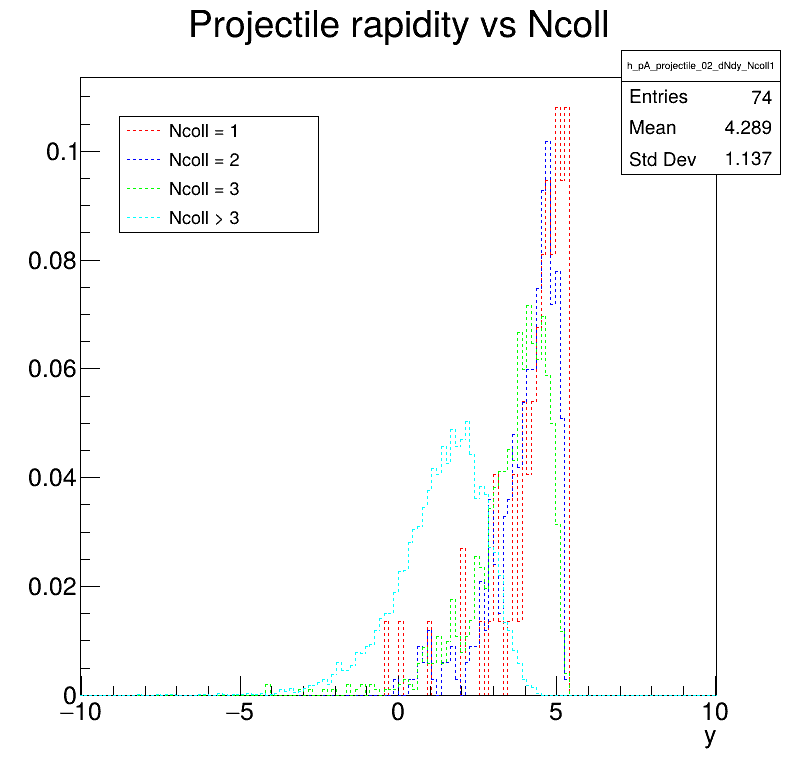

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_02


In [ ]:
auto c_dNdy_Ncoll_02 = new TCanvas("c_dNdy_Ncoll_02", "pA projectile dNdy", 800, 800);

h_pA_projectile_02_dNdy_Ncoll1->GetXaxis()->SetRangeUser(-10,10);
h_pA_projectile_02_dNdy_Ncoll1->GetXaxis()->SetTitle("y");

h_pA_projectile_02_dNdy_Ncoll1->Draw("HIST same");
h_pA_projectile_02_dNdy_Ncoll2->Draw("HIST same");
h_pA_projectile_02_dNdy_Ncoll3->Draw("HIST same");
h_pA_projectile_02_dNdy_NcollL->Draw("HIST same");


auto legend_dNdy_Ncoll_02 = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy_Ncoll_02->AddEntry(h_pA_projectile_02_dNdy_Ncoll1, "Ncoll = 1", "l");
legend_dNdy_Ncoll_02->AddEntry(h_pA_projectile_02_dNdy_Ncoll2, "Ncoll = 2", "l");
legend_dNdy_Ncoll_02->AddEntry(h_pA_projectile_02_dNdy_Ncoll3, "Ncoll = 3", "l");
legend_dNdy_Ncoll_02->AddEntry(h_pA_projectile_02_dNdy_NcollL, "Ncoll = 10", "l");
legend_dNdy_Ncoll_02->Draw();
c_dNdy_Ncoll_02->Draw();

## Separate Comparison

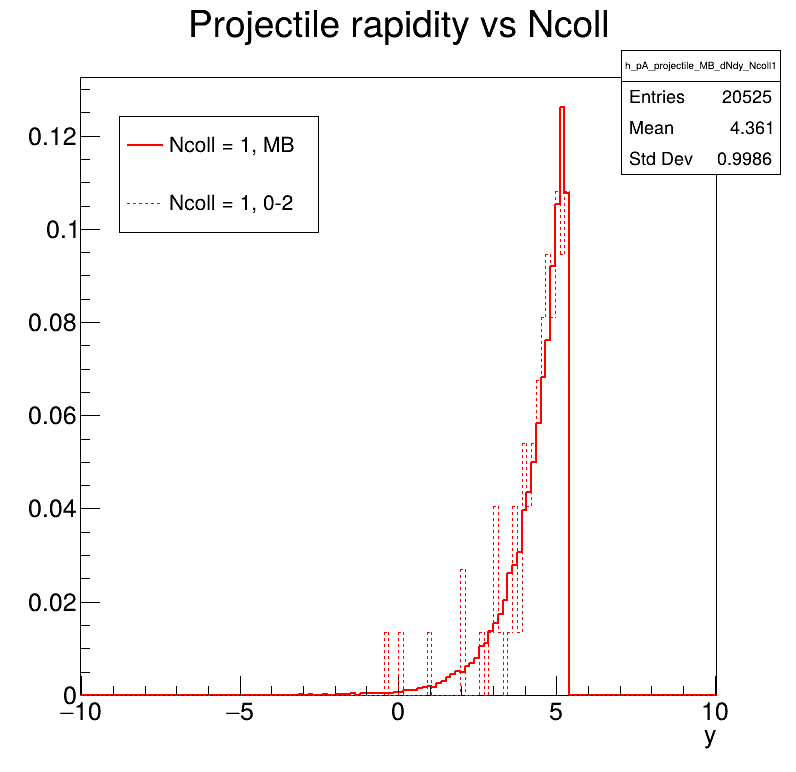

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_cen


In [70]:
auto c_dNdy_Ncoll_cen = new TCanvas("c_dNdy_Ncoll_cen", "pA projectile dNdy", 800, 800);

h_pA_projectile_MB_dNdy_Ncoll1->GetXaxis()->SetRangeUser(-10,10);

h_pA_projectile_MB_dNdy_Ncoll1->Draw("HIST same");
h_pA_projectile_02_dNdy_Ncoll1->Draw("HIST same");


auto legend_dNdy_Ncoll_cen = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_MB_dNdy_Ncoll1, "Ncoll = 1, MB", "l");
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_02_dNdy_Ncoll1, "Ncoll = 1, 0-2", "l");

legend_dNdy_Ncoll_cen->Draw();
c_dNdy_Ncoll_cen->Draw();

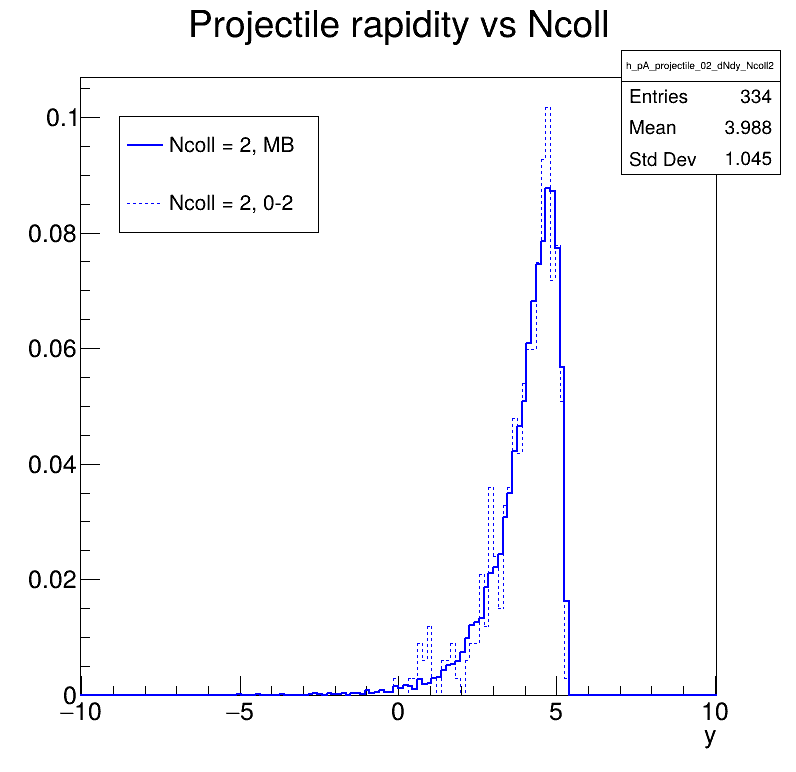

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_cen


In [71]:
auto c_dNdy_Ncoll_cen = new TCanvas("c_dNdy_Ncoll_cen", "pA projectile dNdy", 800, 800);

h_pA_projectile_02_dNdy_Ncoll2->GetXaxis()->SetRangeUser(-10,10);

h_pA_projectile_02_dNdy_Ncoll2->Draw("HIST same");
h_pA_projectile_MB_dNdy_Ncoll2->Draw("HIST same");


auto legend_dNdy_Ncoll_cen = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_MB_dNdy_Ncoll2, "Ncoll = 2, MB", "l");
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_02_dNdy_Ncoll2, "Ncoll = 2, 0-2", "l");

legend_dNdy_Ncoll_cen->Draw();
c_dNdy_Ncoll_cen->Draw();

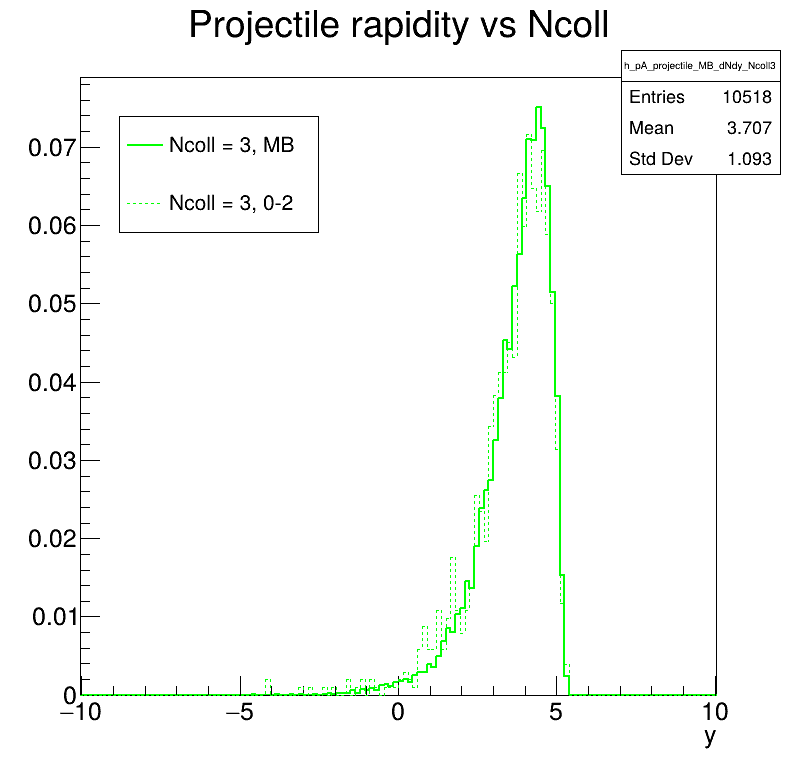

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_cen


In [72]:
auto c_dNdy_Ncoll_cen = new TCanvas("c_dNdy_Ncoll_cen", "pA projectile dNdy", 800, 800);

h_pA_projectile_MB_dNdy_Ncoll3->GetXaxis()->SetRangeUser(-10,10);

h_pA_projectile_MB_dNdy_Ncoll3->Draw("HIST same");
h_pA_projectile_02_dNdy_Ncoll3->Draw("HIST same");


auto legend_dNdy_Ncoll_cen = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_MB_dNdy_Ncoll3, "Ncoll = 3, MB", "l");
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_02_dNdy_Ncoll3, "Ncoll = 3, 0-2", "l");

legend_dNdy_Ncoll_cen->Draw();
c_dNdy_Ncoll_cen->Draw();

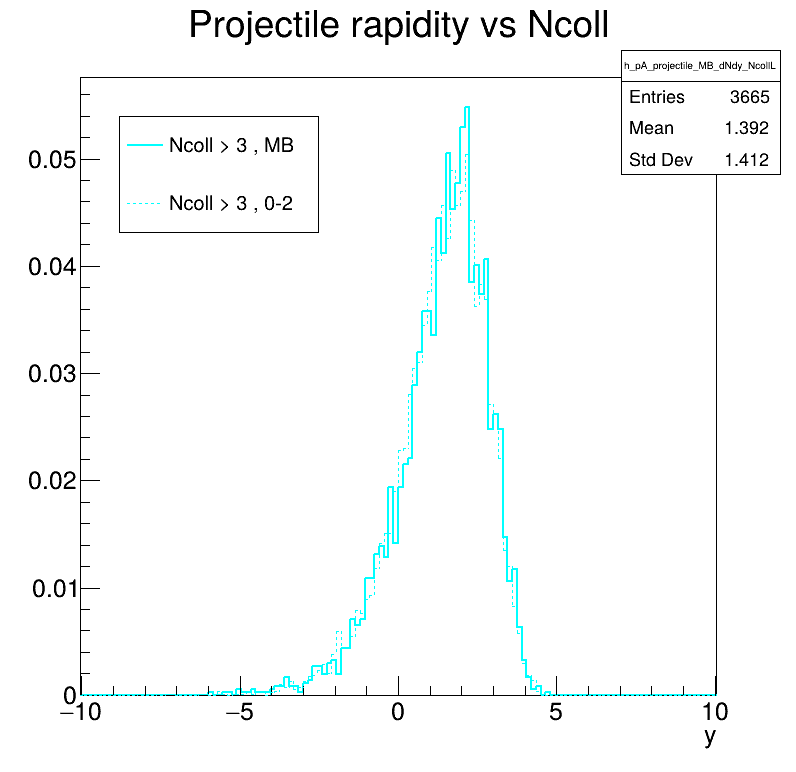

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_cen


In [ ]:
auto c_dNdy_Ncoll_cen = new TCanvas("c_dNdy_Ncoll_cen", "pA projectile dNdy", 800, 800);

h_pA_projectile_MB_dNdy_NcollL->GetXaxis()->SetRangeUser(-10,10);

h_pA_projectile_MB_dNdy_NcollL->Draw("HIST same");
h_pA_projectile_02_dNdy_NcollL->Draw("HIST same");


auto legend_dNdy_Ncoll_cen = new TLegend(0.15,0.7,0.4,0.85);
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_MB_dNdy_NcollL, "Ncoll = 10 , MB", "l");
legend_dNdy_Ncoll_cen->AddEntry(h_pA_projectile_02_dNdy_NcollL, "Ncoll = 10 , 0-2", "l");

legend_dNdy_Ncoll_cen->Draw();
c_dNdy_Ncoll_cen->Draw();

## Reason & explain

To Conclude

Each time of the collision appears to be the same,
Most of the diffences between MB and 0~2 is due to collisions larger than 3 times
This is understandable because the collision time is different


**对于任何一次都是相同的**
**是Ncoll组合的不同产生的rapidity分布的不同**

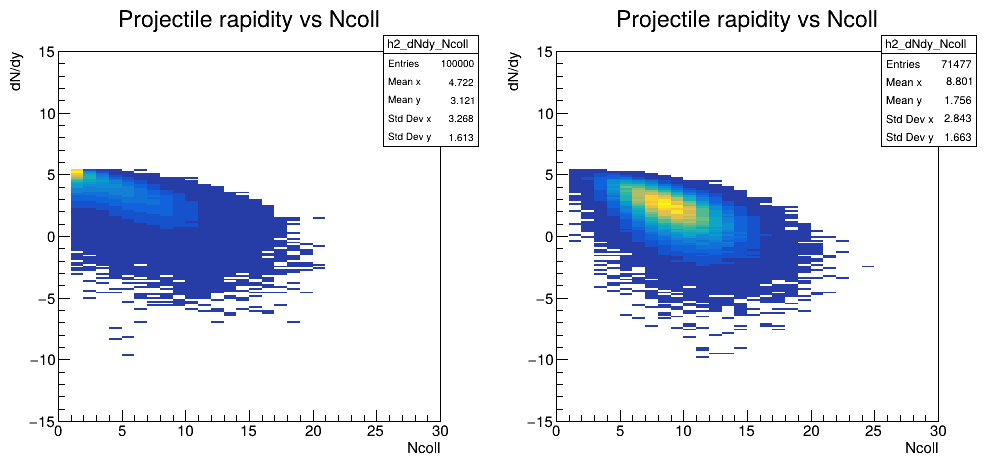

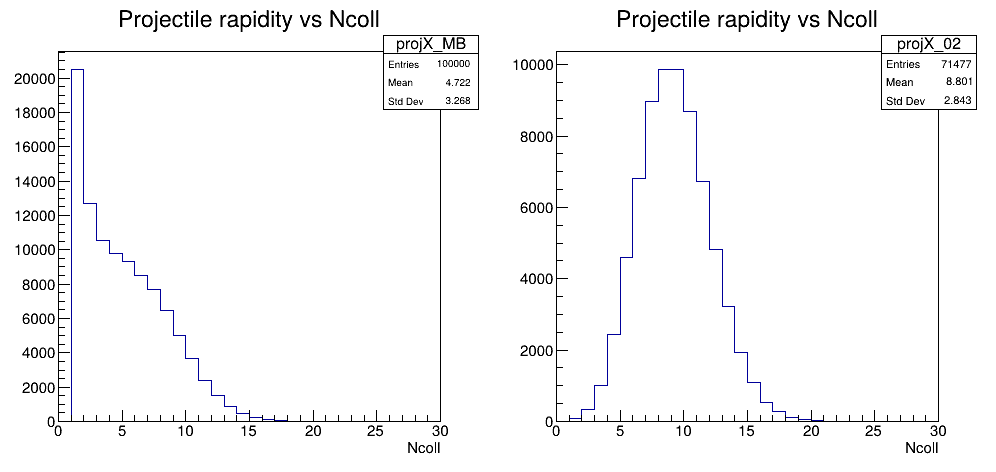

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_dNdy_Ncoll_Compare_MB02
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Ncoll_Compare_MB02


In [74]:
auto c_dNdy_Ncoll_Compare_MB02 = new TCanvas("c_dNdy_Ncoll_Compare_MB02", "pA projectile dNdy", 1000, 500);

c_dNdy_Ncoll_Compare_MB02->Divide(2,1);
c_dNdy_Ncoll_Compare_MB02->cd(1);
h2_pA_projectile_MB_dNdy_Ncoll->Draw();
c_dNdy_Ncoll_Compare_MB02->cd(2);
h2_pA_projectile_02_dNdy_Ncoll->Draw();

c_dNdy_Ncoll_Compare_MB02->Draw();

auto projX_MB = h2_pA_projectile_MB_dNdy_Ncoll->ProjectionX("projX_MB");
auto projX_02 = h2_pA_projectile_02_dNdy_Ncoll->ProjectionX("projX_02");

auto c_Ncoll_Compare_MB02 = new TCanvas("c_Ncoll_Compare_MB02", "pA projectile dNdy", 1000, 500);

c_Ncoll_Compare_MB02->Divide(2,1);
c_Ncoll_Compare_MB02->cd(1);
projX_MB->Draw();
c_Ncoll_Compare_MB02->cd(2);
projX_02->Draw();

c_Ncoll_Compare_MB02->Draw();
